In [1]:
import os
import sys
import torch
import importlib
import pandas as pd
from sklearn.linear_model import Ridge

import utils
import evaluation_metrics as em
from datasets import load_dataset
from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    make_hkan_layer, extend_hkan, set_tqdm_disable,
)
importlib.reload(utils)

/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils' from '/Users/gizemnurdal/Workspace/swim-meets-kans/utils.py'>

# TF1 Experiments

## HKAN

In [2]:
# Load TF1 dataset
tf1 = load_dataset("TF1")
tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = tf1["train_input"], tf1["test_input"], tf1["train_label"], tf1["test_label"]

In [3]:
print("TF1 train describe")
display(pd.DataFrame(tf1_x_train).describe())
print("TF1 test describe")
display(pd.DataFrame(tf1_x_test).describe())
print("TF1 y_train describe")
display(pd.Series(tf1_y_train).describe())
print("TF1 y_test describe")
display(pd.Series(tf1_y_test).describe())

TF1 train describe


,0,1
count,5000.000000,5000.000000
mean,0.502492,0.498871
std,0.291808,0.285606
min,0.000021,0.000020
25%,0.247467,0.253435
50%,0.504131,0.497807
75%,0.758499,0.743126
max,0.999705,0.999692


TF1 test describe


,0,1
count,10000.000000,10000.000000
mean,0.500000,0.500000
std,0.291591,0.291591
min,0.000000,0.000000
25%,0.250000,0.250000
50%,0.500000,0.500000
75%,0.750000,0.750000
max,1.000000,1.000000


TF1 y_train describe


count    5000.000000
mean        0.505381
std         0.166339
min         0.009263
25%         0.414095
50%         0.501150
75%         0.600623
max         0.988818
dtype: float64

TF1 y_test describe


count    10000.000000
mean         0.500000
std          0.170042
min          0.000000
25%          0.404882
50%          0.500000
75%          0.595118
max          1.000000
dtype: float64

In [4]:
# TF1 HKAN model params
tf1_model_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=10),
    }
]
tf1_model = utils.build_hkan_from_params(tf1_model_params)
tf1_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,932
,n_basis,2
,centers,'random_data_points'
,basis_fn,<hkan.hkan.Si...t 0x165b5b990>
,base_regressor,Ridge(alpha=0.1)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [5]:
# Fit HKAN for TF1
utils.fit_hkan(tf1_model,  tf1_x_train, tf1_y_train)
tf1_results = em.evaluate(
    tf1_model,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.69it/s]



✓ HKAN training completed in 4.3401 seconds


In [6]:
em.print_results(tf1_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.088820e-11         1.255516e-11        
RMSE            1.434165e-11         2.642081e-11        


✓ HKAN prediction completed in 2.2804 seconds
✓ Figure saved to results/TF1 HKAN_3d_surface.png


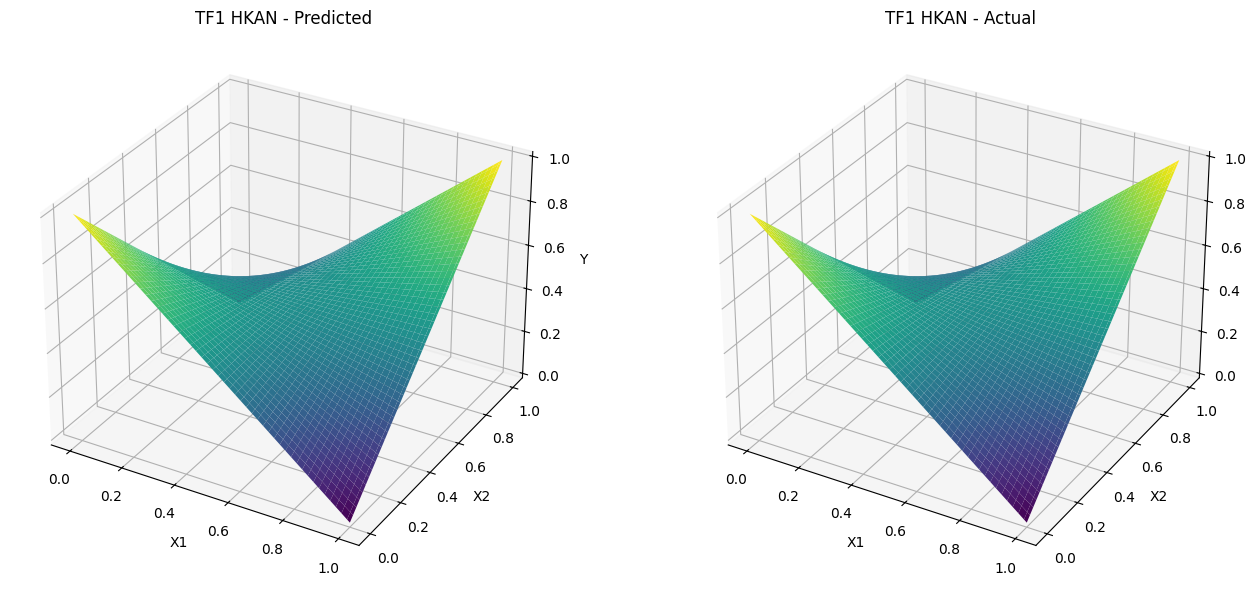

In [7]:
tf1_y_test_pred = utils.predict_hkan(tf1_model, tf1_x_test)
utils.plot_3d_surface("TF1 HKAN", tf1_x_test, tf1_y_test, tf1_y_test_pred)

## KAN

In [8]:
tf1_kan_study = utils.study_optuna_kan("TF1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_trials = 10)

Results found for TF1. Loading from data/tf1_kan_optuna_search.csv
Best CV Validation RMSE: 0.161730
Best Test RMSE:          0.172035
Best width_idx:          2
Best architecture:       [2, 3, 1]

All 10 trials:
   number     value  params_width_idx  val_rmse  test_rmse
0       0  0.161730                 2  0.161730   0.172035
1       1  0.568877                 8  0.568877   0.274214
2       2  0.168665                 4  0.168665   0.298363
3       3  3.752602                 9  3.752602   0.568879
4       4  0.174820                 1  0.174820   0.179805
5       5  0.245464                 6  0.245464   0.178054
6       6  0.198778                 7  0.198778   0.172921
7       7  0.198986                 3  0.198986   0.190309
8       8  0.166398                 0  0.166398   0.170176
9       9  0.573112                 5  0.573112   1.370827


In [9]:
# Create TF1 KAN model with best architecture
tf1_kan_model = utils.build_kan(width=tf1_kan_study["architecture"], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [10]:
# Train and test TF1 KAN model
utils.fit_kan(tf1_kan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, steps=100, opt="Adam", lamb=1e-3)

tf1_kan_results = em.evaluate(
    utils.KANModel(tf1_kan_model),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

| train_loss: 1.67e-01 | test_loss: 1.71e-01 | reg: 2.88e+01 | : 100%|█| 100/100 [00:23<00:00,  4.32

saving model version 0.1

✓ KAN training completed in 23.1802 seconds


In [11]:
em.print_results(tf1_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.261283e-01         1.289797e-01        
RMSE            1.681006e-01         1.720347e-01        


In [12]:
tf1_y_test_pred_kan = utils.predict_kan(tf1_kan_model, tf1_x_test)

✓ KAN prediction completed in 0.0106 seconds


✓ Figure saved to results/TF1 KAN_3d_surface.png


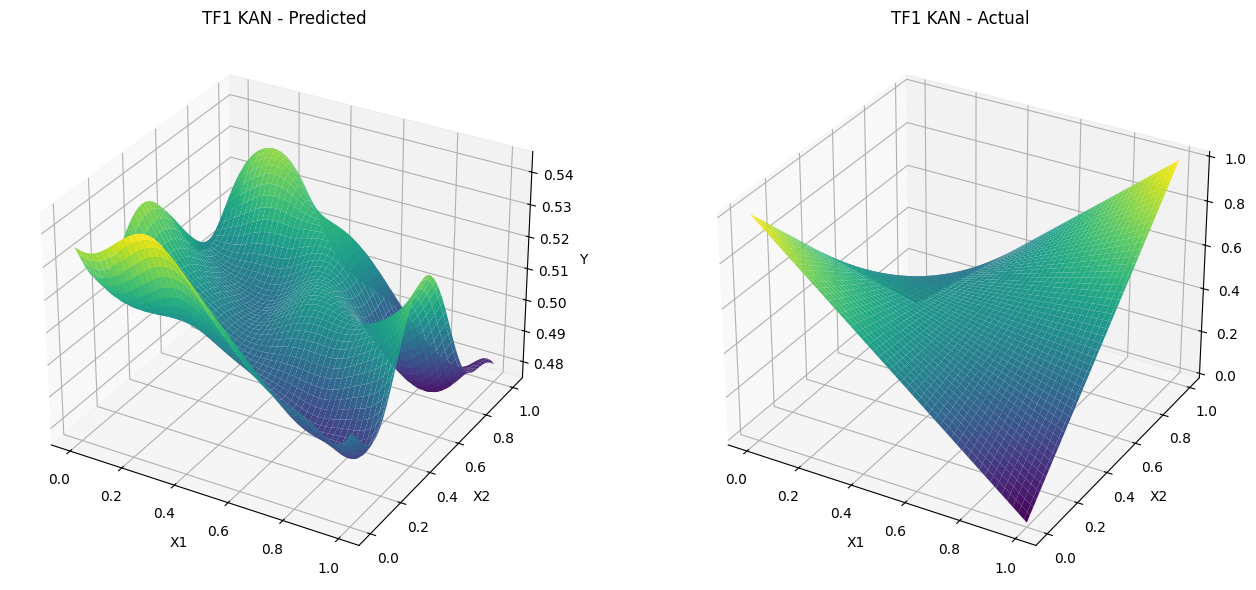

In [13]:
utils.plot_3d_surface("TF1 KAN", tf1_x_test, tf1_y_test, tf1_y_test_pred_kan)

## GP

In [14]:
kernel_types = ["rbf", "matern", "rq"]
tf1_gp_study = utils.study_optuna_gp("TF1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_trials = 10, kernel_types=kernel_types)

Results found for TF1. Loading from data/tf1_gp_optuna_search.csv
Best CV Validation RMSE: 0.019948
Best Test RMSE:          0.023966
Best lr:                 0.019415
Best kernel:             matern
Best num_inducing:       333

All 12 trials:
    number     value  params_lr params_kernel  params_num_inducing  val_rmse  test_rmse
0        0  0.110453   0.000538           rbf                  416  0.110453   0.135136
1        1  0.020348   0.015496        matern                  311  0.020348   0.023110
2        2  0.051657   0.000767            rq                  334  0.051657   0.062964
3        3  0.133662   0.000374           rbf                  421  0.133662   0.161665
4        4  0.055767   0.001536           rbf                  423  0.055767   0.047472
5        5  0.023018   0.004344            rq                  363  0.023018   0.026132
6        6  0.109728   0.000470           rbf                  479  0.109728   0.131682
7        7  0.028892   0.001989            rq      

In [15]:
tf1_gp_study

{'lr': 0.0194151152883173, 'kernel': 'matern', 'num_inducing': 333}

In [16]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf1_gp_study["kernel"], tf1_x_train)
tf1_gp_model, tf1_gp_likelihood = utils.init_and_fit_gp(
    tf1_x_train, tf1_y_train, kernel=kernel,
    num_inducing=tf1_gp_study["num_inducing"], lr=tf1_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf1_gp = utils.GPModel(tf1_gp_model, tf1_gp_likelihood)
tf1_gp_results = em.evaluate(
    tf1_gp,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

em.print_results(tf1_gp_results)

# Make predictions for visualization
tf1_gp_y_test_pred = tf1_gp.predict(tf1_x_test)


Training GP...
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=333

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0194151152883173, loss=ELBO
  Iter 100/500, Loss: 0.745907
  Iter 200/500, Loss: 0.742120
  Iter 300/500, Loss: 0.740923
  Iter 400/500, Loss: 0.740487
  Iter 500/500, Loss: 0.740251
[DEBUG] Training complete.
  Lengthscale: tensor([[1.1852, 0.9842]])
  Kernel type: MaternKernel
  Outputscale: 0.4083
  Noise: 0.693247
  Mean const: 0.3282
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             8.545357e-03         8.925824e-03        
RMSE            1.454207e-02         1.539430e-02        
[DEBUG] SparseG

✓ Figure saved to results/TF1 GP_3d_surface.png


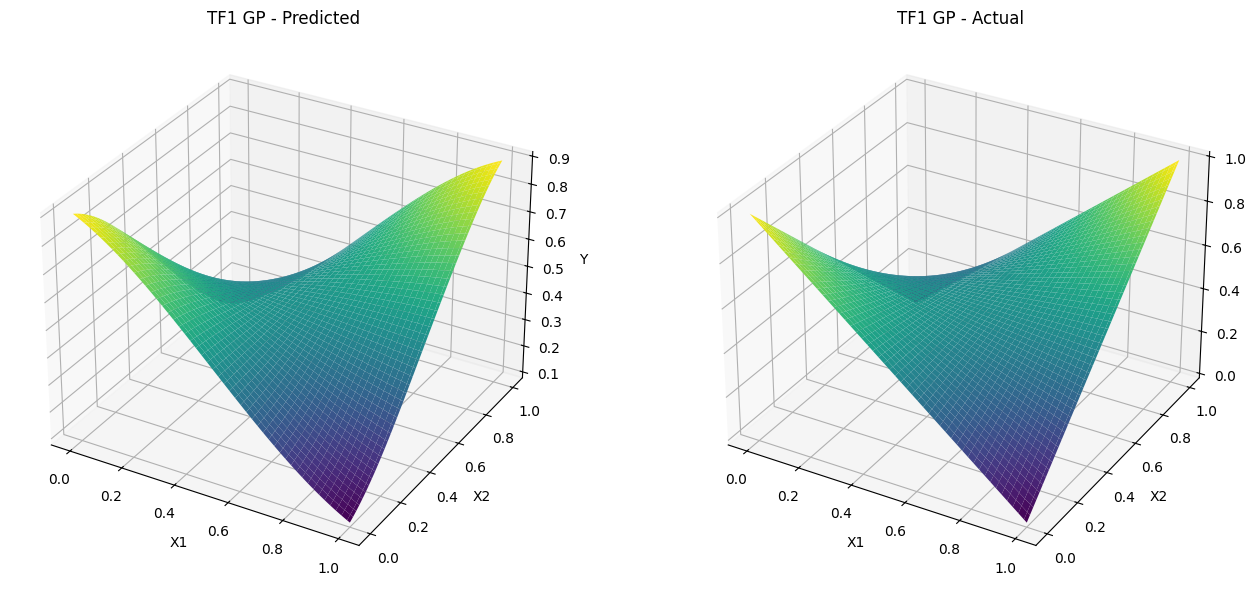

In [17]:
utils.plot_3d_surface("TF1 GP", tf1_x_test, tf1_y_test, tf1_gp_y_test_pred)

## SGKAN

In [18]:
tf1_sgkan_study = utils.study_optuna_sgkan(
    "TF1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_trials = 10,
    kernel=utils.kernel_factory(tf1_gp_study["kernel"], tf1_x_train), lr=tf1_gp_study["lr"], num_inducing=tf1_gp_study["num_inducing"])

Results found for TF1. Loading from data/tf1_sgkan_optuna_search.csv
Best CV Validation RMSE: 0.002533
Best Test RMSE:          0.002487
Best width:              192
Best M:                  692
Best G:                  27
Best T:                  22

All 10 trials:
   number     value  params_width  params_M  params_G  params_T  val_rmse  test_rmse
0       0  0.002867           191       977        73        13  0.002867   0.002692
1       1  0.002533           192       692        27        22  0.002533   0.002487
2       2  0.009680            59       798        75        22  0.009680   0.014344
3       3  0.006059           105       721        62        30  0.006059   0.007755
4       4  0.003199           187       584        96        47  0.003199   0.003396
5       5  0.012711            54       574        93        15  0.012711   0.012540
6       6  0.002929           179       824        77        41  0.002929   0.002842
7       7  0.008277            67       714        82

In [19]:
tf1_sgkan_study

{'width': 192, 'M': 692, 'G': 27, 'T': 22}

In [20]:
# Train TF1 SGKAN (currently uses default RBF kernel)
# To use custom kernel, modify sgkan.build_sgkan to accept kernel parameter
tf1_sgkan_layers, tf1_sgkan_W_out = utils.fit_sgkan(
    tf1_x_train, tf1_y_train, 
    tf1_sgkan_study,
    num_inducing=tf1_gp_study["num_inducing"],
    lr=tf1_gp_study["lr"],
    activation=torch.tanh,
    kernel=utils.kernel_factory(tf1_gp_study["kernel"], tf1_x_train)
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=333
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0194151152883173, loss=ELBO
  Iter 100/500, Loss: 0.744573
  Iter 200/500, Loss: 0.741519
  Iter 300/500, Loss: 0.740767
  Iter 400/500, Loss: 0.740409
  Iter 500/500, Loss: 0.740243
[DEBUG] Training complete.
  Lengthscale: tensor([[1.2106, 0.9694]])
  Kernel type: MaternKernel
  Outputscale: 0.4273
  Noise: 0.693247
  Mean const: 0.2250
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0426, max=2.2054, mean=1.0545
[DEBUG] Probs:  min=0.000058,  max=0.003022,  sum=1.000000
[DEBUG] Selected 192 pairs from 692 candidates
[DEBUG] Unique pairs selected: 174 / 192
[DEBUG] x_segments shape:     torch.Size([192, 27, 2])
[DEBUG] edge_functions shape: torch.Size([192, 27])
[DEBUG] Value range: [0.1030, 0.8740]
[DEBUG] H shape

In [21]:
tf1_sgkan_results = em.evaluate(
    utils.SGKANModel(tf1_sgkan_layers, tf1_sgkan_W_out, activation=torch.tanh),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

[DEBUG] H shape: torch.Size([5000, 192])
[DEBUG] H value range: [0.1030, 0.8740]
[DEBUG] H rank (approx): 174
[DEBUG] H shape: torch.Size([10000, 192])
[DEBUG] H value range: [0.1030, 0.8740]
[DEBUG] H rank (approx): 174


In [22]:
em.print_results(tf1_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.421383e-03         1.548959e-03        
RMSE            1.935540e-03         2.176225e-03        


In [23]:
tf1_sgkan_y_test_pred = utils.predict_sgkan(tf1_sgkan_layers, tf1_sgkan_W_out, tf1_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([10000, 192])
[DEBUG] H value range: [0.1030, 0.8740]
[DEBUG] H rank (approx): 174
✓ Prediction completed in 0.0547 seconds


✓ Figure saved to results/TF1 SGKAN_3d_surface.png


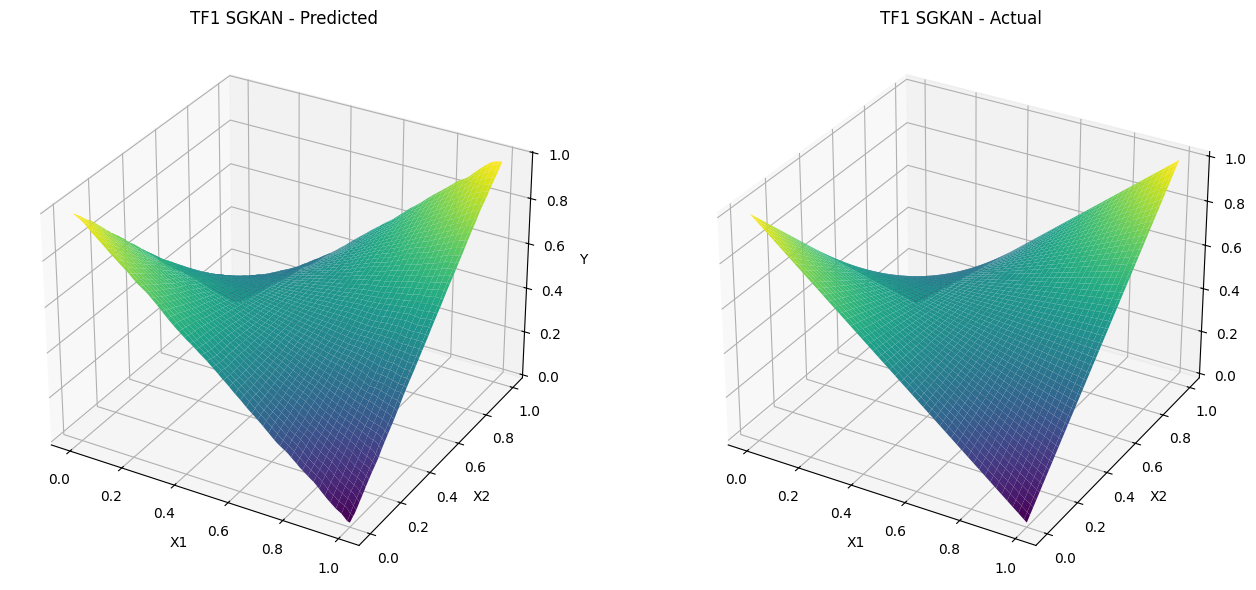

In [24]:
utils.plot_3d_surface("TF1 SGKAN", tf1_x_test, tf1_y_test, tf1_sgkan_y_test_pred)

# TF2 Experiments

## HKAN

In [25]:
# Load TF2 dataset
tf2 = load_dataset("TF2")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = tf2["train_input"], tf2["test_input"], tf2["train_label"], tf2["test_label"]

In [26]:
print("TF2 train describe")
display(pd.DataFrame(tf2_x_train).describe())
print("TF2 test describe")
display(pd.DataFrame(tf2_x_test).describe())
print("TF2 y_train describe")
display(pd.Series(tf2_y_train).describe())
print("TF2 y_test describe")
display(pd.Series(tf2_y_test).describe())

TF2 train describe


,0,1
count,5000.000000,5000.000000
mean,0.502861,0.502000
std,0.285424,0.285515
min,0.000133,0.000387
25%,0.259877,0.257710
50%,0.504340,0.502470
75%,0.747827,0.747088
max,0.999850,0.999980


TF2 test describe


,0,1
count,10000.000000,10000.000000
mean,0.500000,0.500000
std,0.291591,0.291591
min,0.000000,0.000000
25%,0.250002,0.250002
50%,0.500000,0.500000
75%,0.749997,0.749997
max,1.000000,1.000000


TF2 y_train describe


count    5000.000000
mean        0.482074
std         0.173621
min        -0.103030
25%         0.356747
50%         0.477600
75%         0.603375
max         1.145400
dtype: float64

TF2 y_test describe


count    10000.000000
mean         0.481887
std          0.129811
min          0.000000
25%          0.405035
50%          0.478680
75%          0.555480
max          1.000000
dtype: float64

In [27]:
# TF2 HKAN model params
tf2_model_params = [
    {
        "layer": 0,
        "n_vars_out": 48,
        "basis_fn": Tanh(s=22),
        "n_basis": 17,
        "centers": "random",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 11,
        "basis_fn": Softplus(s=18),
        "n_basis": 21,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=1),
    },
    {
        "layer": 2,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        # Default configuration
        "n_basis": 10,
        "centers": "random",
        "regressor": Ridge(),
    }
]
tf2_model = utils.build_hkan_from_params(tf2_model_params)
tf2_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,48
,n_basis,17
,centers,'random'
,basis_fn,<hkan.hkan.Ta...t 0x16943cd90>
,base_regressor,Ridge(alpha=0.1)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [28]:
# Fit HKAN for TF2
utils.fit_hkan(tf2_model, tf2_x_train, tf2_y_train)
tf2_results = em.evaluate(
    tf2_model,
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 588.59it/s]



✓ HKAN training completed in 2.1344 seconds


In [29]:
em.print_results(tf2_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.008521e-01         1.348625e-02        
RMSE            1.163214e-01         1.698008e-02        


✓ HKAN prediction completed in 1.6697 seconds
✓ Figure saved to results/TF2 HKAN_3d_surface.png


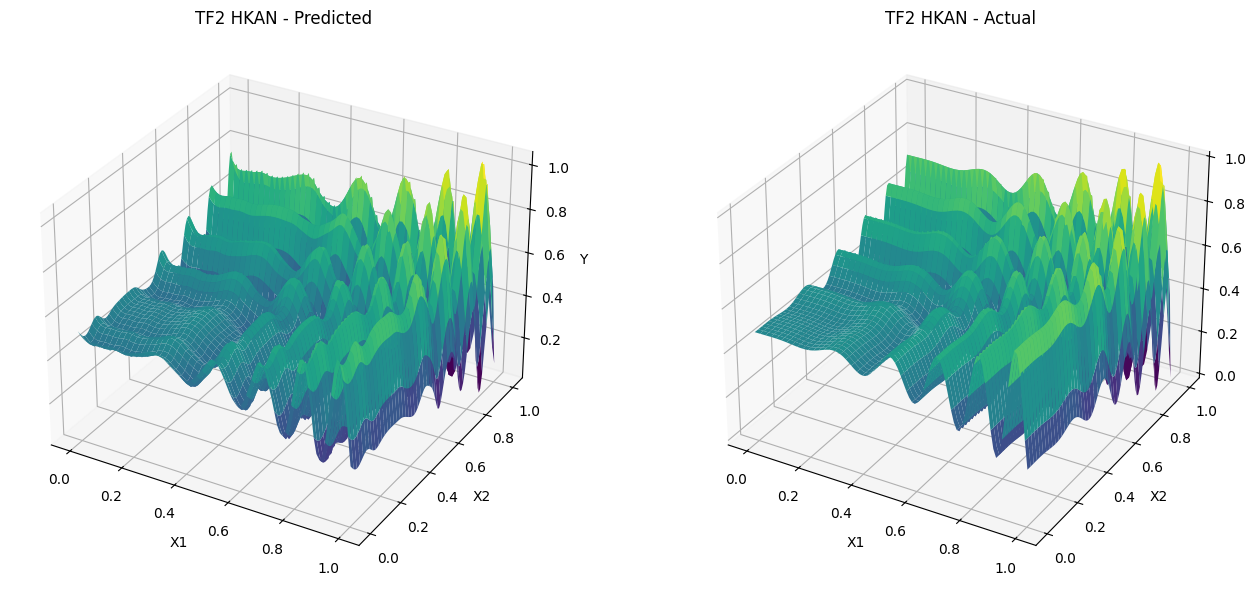

In [30]:
tf2_y_test_pred = utils.predict_hkan(tf2_model, tf2_x_test)
utils.plot_3d_surface("TF2 HKAN", tf2_x_test, tf2_y_test, tf2_y_test_pred)

## KAN

In [31]:
tf2_kan_study = utils.study_optuna_kan("TF2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, n_trials=10)

Results found for TF2. Loading from data/tf2_kan_optuna_search.csv
Best CV Validation RMSE: 0.173447
Best Test RMSE:          0.129826
Best width_idx:          0
Best architecture:       [2, 1]

All 10 trials:
   number     value  params_width_idx  val_rmse  test_rmse
0       0  0.220154                 2  0.220154   0.134638
1       1  0.255157                 8  0.255157  10.841902
2       2  0.214038                 4  0.214038   0.239839
3       3  2.014279                 9  2.014279   0.431603
4       4  0.242890                 1  0.242890   0.132069
5       5  0.198356                 6  0.198356   0.130486
6       6  0.313805                 7  0.313805   0.488357
7       7  0.197938                 3  0.197938   0.181680
8       8  0.173447                 0  0.173447   0.129826
9       9  4.529024                 5  4.529024   0.473081


In [32]:
tf2_kan_model = utils.build_kan(width=tf2_kan_study["architecture"], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [33]:
utils.fit_kan(tf2_kan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, steps=100, opt="Adam", lamb=1e-3)

tf2_kan_results = em.evaluate(
    utils.KANModel(tf2_kan_model),
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

| train_loss: 1.74e-01 | test_loss: 1.30e-01 | reg: 3.84e-01 | : 100%|█| 100/100 [00:19<00:00,  5.13

saving model version 0.1

✓ KAN training completed in 19.5174 seconds


In [34]:
em.print_results(tf2_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.403017e-01         9.761542e-02        
RMSE            1.734280e-01         1.298259e-01        


✓ KAN prediction completed in 0.0056 seconds
✓ Figure saved to results/TF2 KAN_3d_surface.png


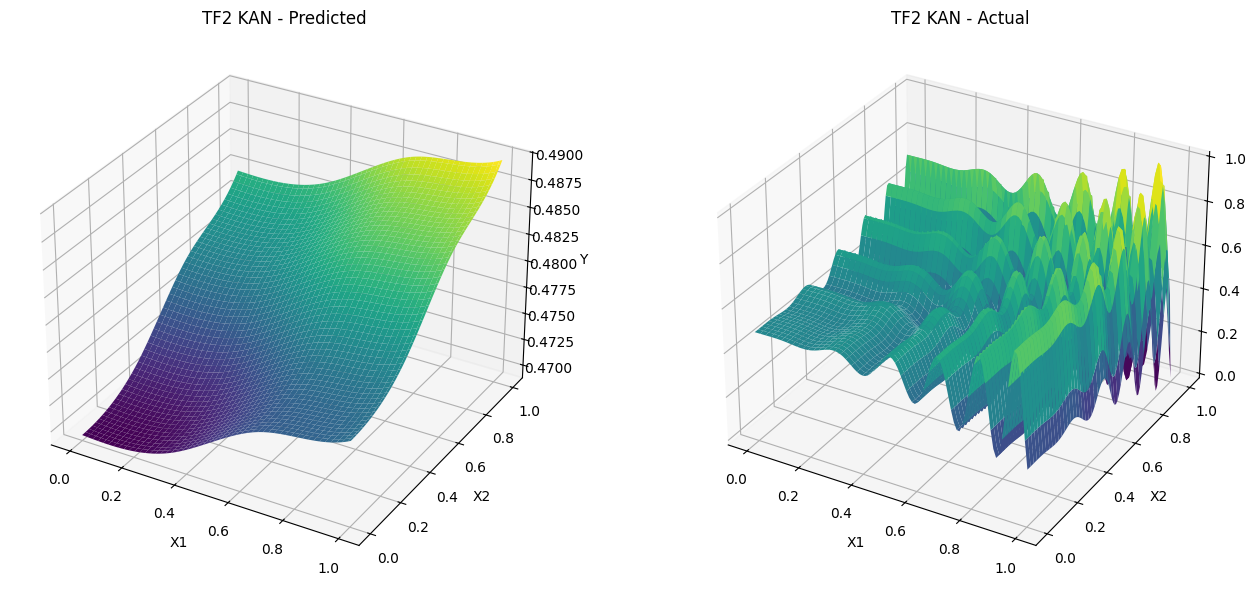

In [35]:
tf2_y_test_pred_kan = utils.predict_kan(tf2_kan_model, tf2_x_test)
utils.plot_3d_surface("TF2 KAN", tf2_x_test, tf2_y_test, tf2_y_test_pred_kan)

## GP

In [36]:
kernel_types = ["periodic", "periodic_rbf"]
tf2_gp_study = utils.study_optuna_gp("TF2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, n_trials = 10, kernel_types=kernel_types)

Results found for TF2. Loading from data/tf2_gp_optuna_search.csv
Best CV Validation RMSE: 0.171319
Best Test RMSE:          0.130506
Best lr:                 0.003427
Best kernel:             periodic_rbf
Best num_inducing:       432

All 10 trials:
   number     value  params_lr params_kernel  params_num_inducing  val_rmse  test_rmse
0       0  0.173106   0.025714      periodic                  382  0.173106   0.129803
1       1  0.332258   0.000109  periodic_rbf                  485  0.332258   0.318200
2       2  0.172201   0.010143      periodic                  469  0.172201   0.129750
3       3  0.171545   0.003436      periodic                  383  0.171545   0.129561
4       4  0.171319   0.003427  periodic_rbf                  432  0.171319   0.130506
5       5  0.173420   0.043263  periodic_rbf                  420  0.173420   0.129804
6       6  0.173423   0.041908      periodic                  330  0.173423   0.129804
7       7  0.171424   0.006274      periodic         

In [37]:
tf2_gp_study

{'lr': 0.0034272891021517, 'kernel': 'periodic_rbf', 'num_inducing': 432}

In [38]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf2_gp_study["kernel"], tf2_x_train)
tf2_gp_model, tf2_gp_likelihood = utils.init_and_fit_gp(
    tf2_x_train, tf2_y_train, kernel=kernel,
    num_inducing=tf2_gp_study["num_inducing"], lr=tf2_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf2_gp = utils.GPModel(tf2_gp_model, tf2_gp_likelihood)
tf2_gp_results = em.evaluate(
    tf2_gp,
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

em.print_results(tf2_gp_results)

# Make predictions for visualization
tf2_gp_y_test_pred = tf2_gp.predict(tf2_x_test)


Training GP...
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=432

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0034272891021517, loss=ELBO
  Iter 100/500, Loss: 0.825643
  Iter 200/500, Loss: 0.796056
  Iter 300/500, Loss: 0.785786
  Iter 400/500, Loss: 0.780320
  Iter 500/500, Loss: 0.777016
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.4920
  Noise: 0.693247
  Mean const: 0.1976
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             1.295708e-01         8.426158e-02        
RMSE            1.597093e-01         1.152217e-01        
[DEBUG] Spa

✓ Figure saved to results/TF2 GP_3d_surface.png


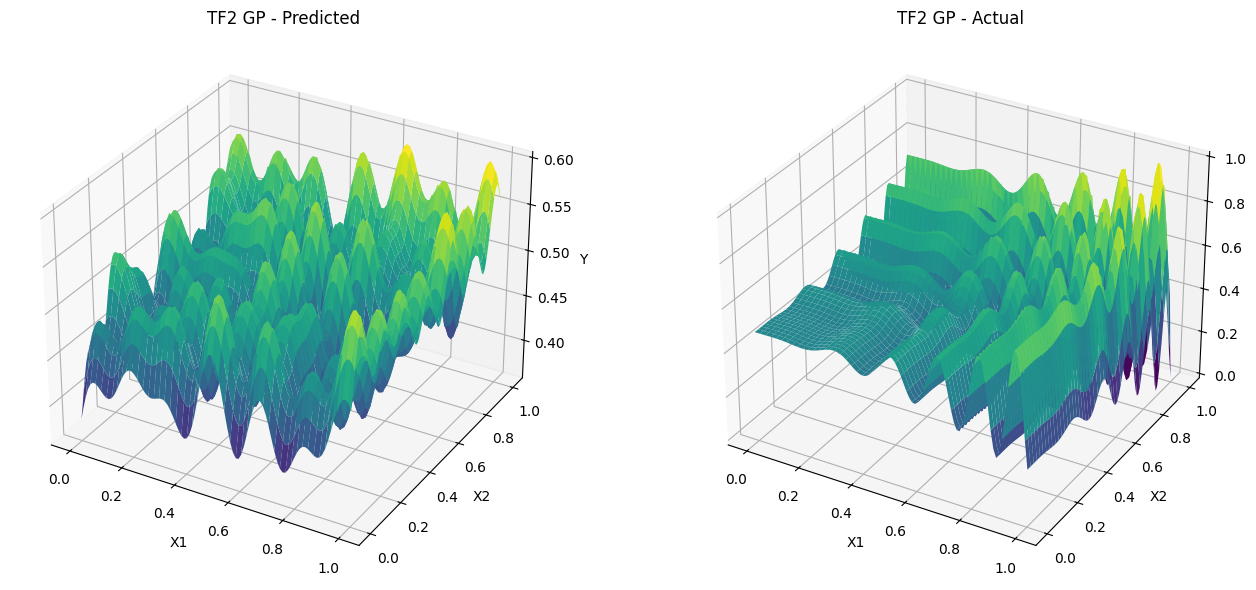

In [39]:
utils.plot_3d_surface("TF2 GP", tf2_x_test, tf2_y_test, tf2_gp_y_test_pred)

## SGKAN

In [40]:
tf2_sgkan_study = utils.study_optuna_sgkan(
    "TF2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, n_trials = 10,
    kernel=utils.kernel_factory(tf2_gp_study["kernel"], tf2_x_train), lr=tf2_gp_study["lr"], num_inducing=tf2_gp_study["num_inducing"])

Results found for TF2. Loading from data/tf2_sgkan_optuna_search.csv
Best CV Validation RMSE: 0.158036
Best Test RMSE:          0.113118
Best width:              151
Best M:                  631
Best G:                  58
Best T:                  9

All 10 trials:
   number     value  params_width  params_M  params_G  params_T  val_rmse  test_rmse
0       0  0.169089           109       534        62         5  0.169089   0.127265
1       1  0.161646           105       865        87        47  0.161646   0.121954
2       2  0.158036           151       631        58         9  0.158036   0.113118
3       3  0.170618            41       674        87        33  0.170618   0.124583
4       4  0.164706           104       975        35        14  0.164706   0.111565
5       5  0.163527            43       639        71        42  0.163527   0.129617
6       6  0.164859            77       643        86        17  0.164859   0.114953
7       7  0.167502            53       546        89 

In [41]:
tf2_sgkan_study

{'width': 151, 'M': 631, 'G': 58, 'T': 9}

In [42]:
tf2_sgkan_layers, tf2_sgkan_W_out = utils.fit_sgkan(
    tf2_x_train, tf2_y_train, 
    tf2_sgkan_study,
    num_inducing=tf2_gp_study["num_inducing"],
    lr=tf2_gp_study["lr"],
    activation=torch.tanh,
    kernel=utils.kernel_factory(tf2_gp_study["kernel"], tf2_x_train)
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=432
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0034272891021517, loss=ELBO
  Iter 100/500, Loss: 0.825569
  Iter 200/500, Loss: 0.795066
  Iter 300/500, Loss: 0.784633
  Iter 400/500, Loss: 0.779449
  Iter 500/500, Loss: 0.776403
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.4943
  Noise: 0.693247
  Mean const: 0.1962
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0257, max=2.7610, mean=0.8579
[DEBUG] Probs:  min=0.000047,  max=0.005100,  sum=1.000000
[DEBUG] Selected 151 pairs from 631 candidates
[DEBUG] Unique pairs selected: 132 / 151
[DEBUG] x_segments shape:     torch.Size([151, 58, 2])
[DEBUG] edge_functions shape: torch.Size([151, 58])
[DEBUG] Value range: [0.3906, 0.6185]
[DEBUG] H s

In [43]:
tf2_sgkan_results = em.evaluate(
    utils.SGKANModel(tf2_sgkan_layers, tf2_sgkan_W_out, activation=torch.tanh),
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

[DEBUG] H shape: torch.Size([5000, 151])
[DEBUG] H value range: [0.3906, 0.6185]
[DEBUG] H rank (approx): 132
[DEBUG] H shape: torch.Size([10000, 151])
[DEBUG] H value range: [0.3906, 0.6185]
[DEBUG] H rank (approx): 132


In [44]:
em.print_results(tf2_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.233694e-01         7.393727e-02        
RMSE            1.524692e-01         1.085340e-01        


In [45]:
tf2_sgkan_y_test_pred = utils.predict_sgkan(tf2_sgkan_layers, tf2_sgkan_W_out, tf2_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([10000, 151])
[DEBUG] H value range: [0.3906, 0.6185]
[DEBUG] H rank (approx): 132
✓ Prediction completed in 0.0435 seconds


✓ Figure saved to results/TF2 SGKAN_3d_surface.png


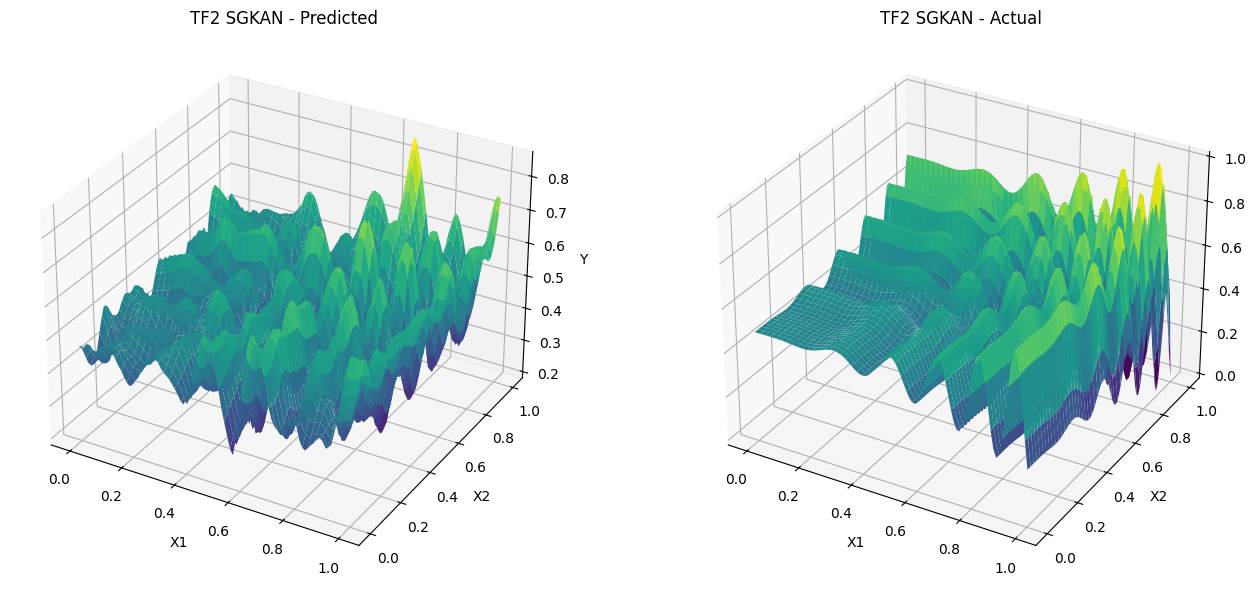

In [46]:
utils.plot_3d_surface("TF2 SGKAN", tf2_x_test, tf2_y_test, tf2_sgkan_y_test_pred)

# TF3 Experiments

## HKAN

In [47]:
# Load TF3 dataset
tf3 = load_dataset("TF3")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = tf3["train_input"], tf3["test_input"], tf3["train_label"], tf3["test_label"]

In [48]:
print("TF3 train describe")
display(pd.DataFrame(tf3_x_train).describe())
print("TF3 test describe")
display(pd.DataFrame(tf3_x_test).describe())
print("TF3 y_train describe")
display(pd.Series(tf3_y_train).describe())
print("TF3 y_test describe")
display(pd.Series(tf3_y_test).describe())

TF3 train describe


,0,1
count,5000.000000,5000.000000
mean,0.504802,0.500059
std,0.286061,0.284858
min,0.000433,0.000133
25%,0.261751,0.255484
50%,0.507392,0.498916
75%,0.749510,0.745363
max,0.999891,0.999982


TF3 test describe


,0,1
count,10000.000000,10000.000000
mean,0.500000,0.500000
std,0.291591,0.291591
min,0.000000,0.000000
25%,0.250000,0.250000
50%,0.500000,0.500000
75%,0.750000,0.750000
max,1.000000,1.000000


TF3 y_train describe


count    5000.000000
mean        0.502180
std         0.161040
min         0.005368
25%         0.392510
50%         0.501351
75%         0.612301
max         0.990860
dtype: float64

TF3 y_test describe


count    10000.000000
mean         0.500000
std          0.163565
min          0.000000
25%          0.388427
50%          0.500000
75%          0.611573
max          1.000000
dtype: float64

In [49]:
# TF3 HKAN model params
tf3_model_params = [
    {
        "layer": 0,
        "n_vars_out": 924,
        "basis_fn": Tanh(s=50),
        "n_basis": 39,
        "centers": "random",
        "regressor": Ridge(alpha=0.001),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(),
    }
]
tf3_model = utils.build_hkan_from_params(tf3_model_params)
tf3_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,924
,n_basis,39
,centers,'random'
,basis_fn,<hkan.hkan.Ta...t 0x31d10f590>
,base_regressor,Ridge(alpha=0.001)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [50]:
# Fit HKAN for TF3
utils.fit_hkan(tf3_model, tf3_x_train, tf3_y_train)
tf3_results = em.evaluate(
    tf3_model,
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.77it/s]



✓ HKAN training completed in 15.5452 seconds


In [51]:
em.print_results(tf3_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             3.754846e-06         3.888678e-06        
RMSE            9.324212e-06         6.590566e-06        


✓ HKAN prediction completed in 9.7578 seconds
✓ Figure saved to results/TF3 HKAN_3d_surface.png


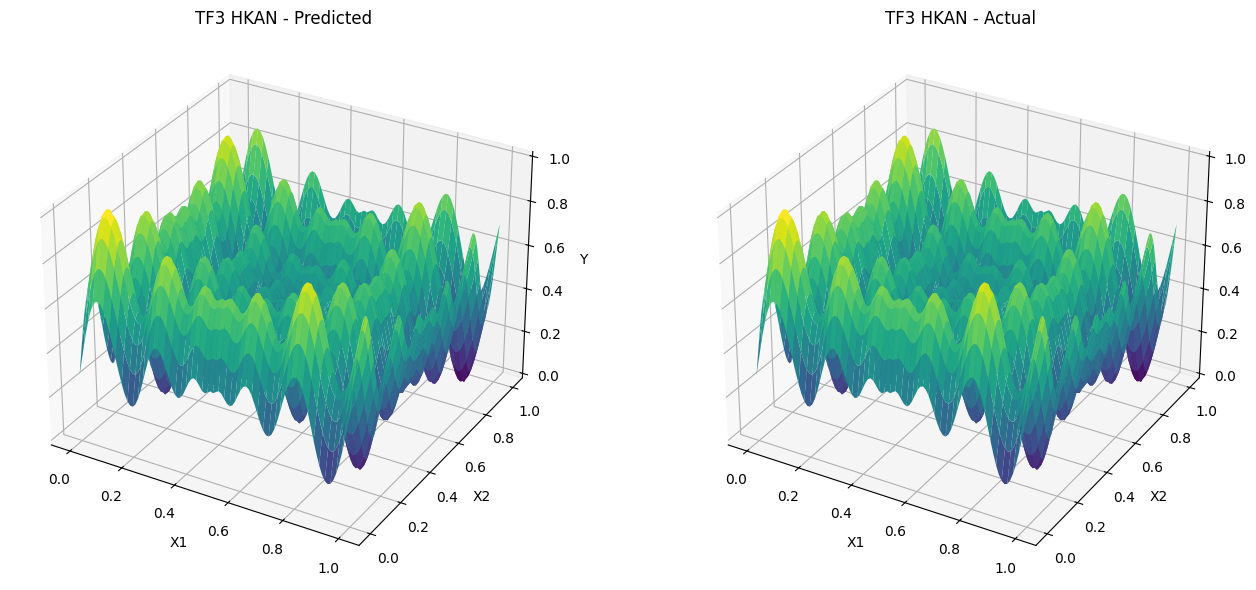

In [52]:
tf3_y_test_pred = utils.predict_hkan(tf3_model, tf3_x_test)
utils.plot_3d_surface("TF3 HKAN", tf3_x_test, tf3_y_test, tf3_y_test_pred)

## KAN

In [53]:
tf3_kan_study = utils.study_optuna_kan("TF3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, n_trials=10)

Results found for TF3. Loading from data/tf3_kan_optuna_search.csv
Best CV Validation RMSE: 0.162384
Best Test RMSE:          0.164722
Best width_idx:          0
Best architecture:       [2, 1]

All 10 trials:
   number     value  params_width_idx  val_rmse  test_rmse
0       0  0.399037                 2  0.399037   0.160471
1       1  0.172992                 8  0.172992   0.164513
2       2  0.286203                 4  0.286203   0.163476
3       3  0.999206                 9  0.999206   0.163668
4       4  0.164660                 1  0.164660   0.487747
5       5  0.163563                 6  0.163563   0.163949
6       6  1.370679                 7  1.370679   0.361969
7       7  0.170057                 3  0.170057   0.182046
8       8  0.162384                 0  0.162384   0.164722
9       9  0.222863                 5  0.222863   0.196609


In [54]:
tf3_kan_model = utils.build_kan(width=tf3_kan_study["architecture"], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [55]:
utils.fit_kan(tf3_kan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, steps=100, opt="Adam", lamb=1e-3)

tf3_kan_results = em.evaluate(
    utils.KANModel(tf3_kan_model),
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

| train_loss: 1.61e-01 | test_loss: 1.64e-01 | reg: 2.67e-01 | : 100%|█| 100/100 [00:20<00:00,  4.94

saving model version 0.1

✓ KAN training completed in 20.2459 seconds


In [56]:
em.print_results(tf3_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.298408e-01         1.316747e-01        
RMSE            1.622684e-01         1.647225e-01        


✓ KAN prediction completed in 0.0055 seconds
✓ Figure saved to results/TF3 KAN_3d_surface.png


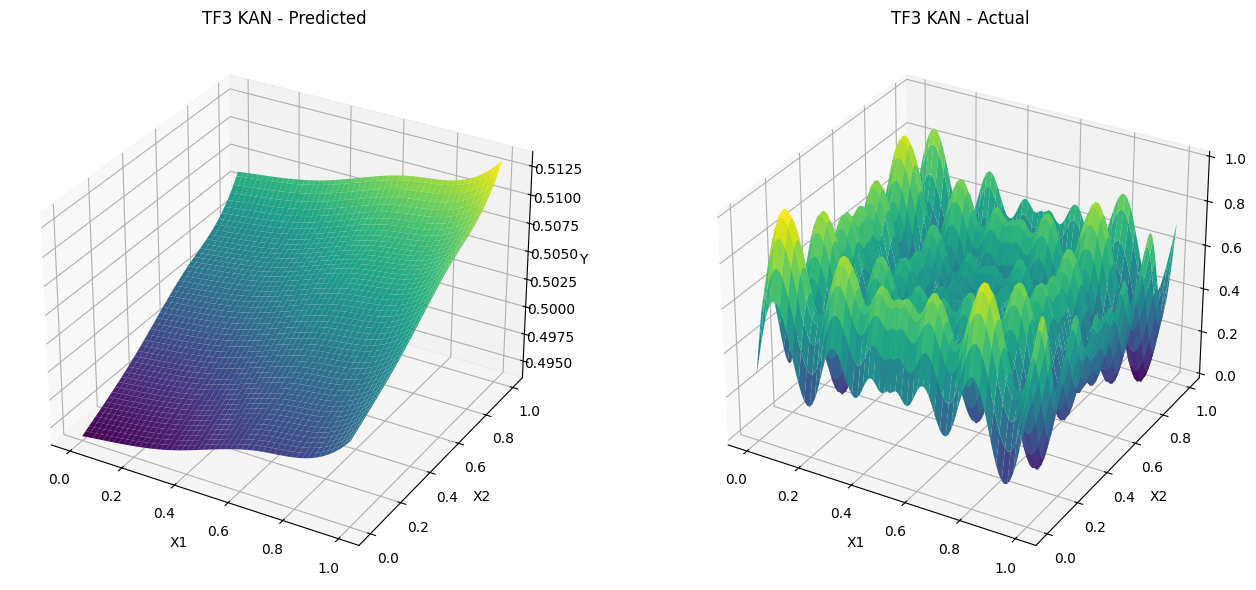

In [57]:
tf3_y_test_pred_kan = utils.predict_kan(tf3_kan_model, tf3_x_test)
utils.plot_3d_surface("TF3 KAN", tf3_x_test, tf3_y_test, tf3_y_test_pred_kan)

## GP

In [58]:
kernel_types = ["periodic", "periodic_rbf", "periodic_linear"]
tf3_gp_study = utils.study_optuna_gp("TF3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, n_trials = 10, kernel_types=kernel_types)

Results found for TF3. Loading from data/tf3_gp_optuna_search.csv
Best CV Validation RMSE: 0.095773
Best Test RMSE:          0.113155
Best lr:                 0.011154
Best kernel:             periodic_rbf
Best num_inducing:       386

All 10 trials:
   number     value  params_lr    params_kernel  params_num_inducing  val_rmse  test_rmse
0       0  0.098274   0.015428         periodic                  339  0.098274   0.117043
1       1  0.117404   0.000854     periodic_rbf                  491  0.117404   0.114620
2       2  0.115431   0.003727  periodic_linear                  474  0.115431   0.125627
3       3  0.110777   0.043533     periodic_rbf                  361  0.110777   0.114823
4       4  0.107140   0.032725         periodic                  390  0.107140   0.118038
5       5  0.123379   0.002168  periodic_linear                  420  0.123379   0.125513
6       6  0.115578   0.007485  periodic_linear                  468  0.115578   0.122938
7       7  0.347913   0.00016

In [59]:
tf3_gp_study

{'lr': 0.0111535300454851, 'kernel': 'periodic_rbf', 'num_inducing': 386}

In [60]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf3_gp_study["kernel"], tf3_x_train)
tf3_gp_model, tf3_gp_likelihood = utils.init_and_fit_gp(
    tf3_x_train, tf3_y_train, kernel=kernel,
    num_inducing=tf3_gp_study["num_inducing"], lr=tf3_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf3_gp = utils.GPModel(tf3_gp_model, tf3_gp_likelihood)
tf3_gp_results = em.evaluate(
    tf3_gp,
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

em.print_results(tf3_gp_results)

# Make predictions for visualization
tf3_gp_y_test_pred = tf3_gp.predict(tf3_x_test)


Training GP...
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=386

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0111535300454851, loss=ELBO
  Iter 100/500, Loss: 0.768220
  Iter 200/500, Loss: 0.760248
  Iter 300/500, Loss: 0.757101
  Iter 400/500, Loss: 0.755929
  Iter 500/500, Loss: 0.755129
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.3770
  Noise: 0.693247
  Mean const: 0.2381
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             5.390276e-02         5.666193e-02        
RMSE            6.652936e-02         7.006264e-02        
[DEBUG] Spa

✓ Figure saved to results/TF3 GP_3d_surface.png


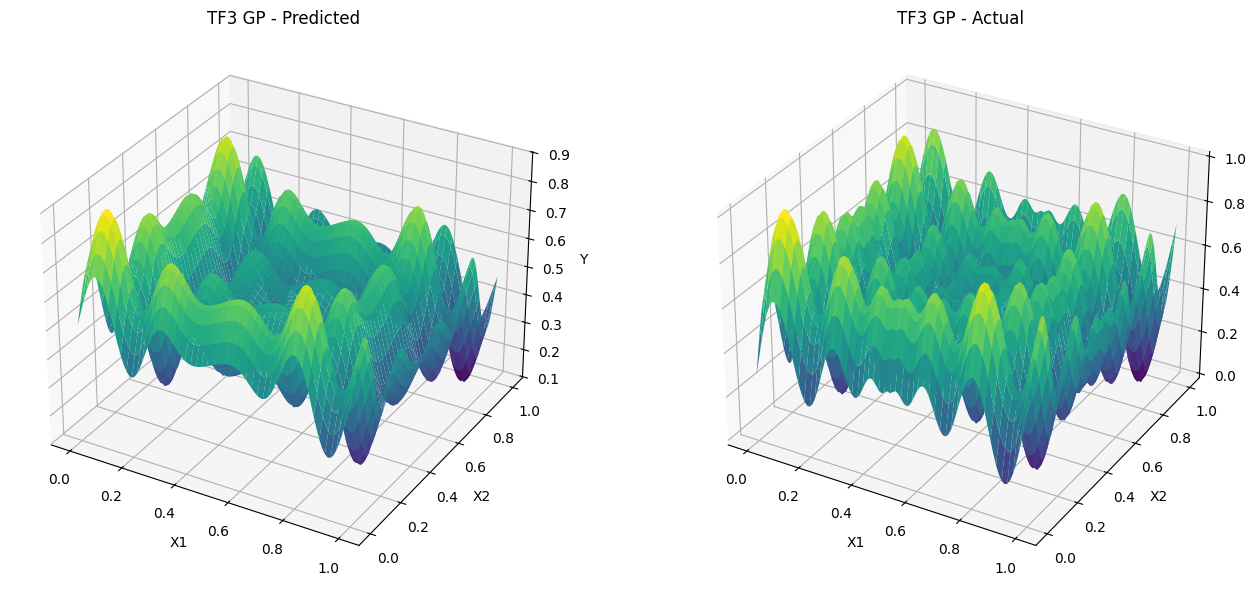

In [61]:
utils.plot_3d_surface("TF3 GP", tf3_x_test, tf3_y_test, tf3_gp_y_test_pred)

## SGKAN

In [62]:
tf3_sgkan_study = utils.study_optuna_sgkan(
    "TF3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, n_trials = 10,
    kernel=utils.kernel_factory(tf3_gp_study["kernel"], tf3_x_train), lr=tf3_gp_study["lr"], num_inducing=tf3_gp_study["num_inducing"])

Results found for TF3. Loading from data/tf3_sgkan_optuna_search.csv
Best CV Validation RMSE: 0.068252
Best Test RMSE:          0.073501
Best width:              192
Best M:                  687
Best G:                  61
Best T:                  45

All 10 trials:
   number     value  params_width  params_M  params_G  params_T  val_rmse  test_rmse
0       0  0.092846           104       651        79        25  0.092846   0.108666
1       1  0.094298           124       506        52        40  0.094298   0.086664
2       2  0.068252           192       687        61        45  0.068252   0.073501
3       3  0.107465            69       880        43        46  0.107465   0.114640
4       4  0.081396           156       516        57        40  0.081396   0.058668
5       5  0.099271            97       682        58         8  0.099271   0.096330
6       6  0.120915            40       913        85        48  0.120915   0.136194
7       7  0.078196           154       770        65

In [63]:
tf3_sgkan_study

{'width': 192, 'M': 687, 'G': 61, 'T': 45}

In [64]:
tf3_sgkan_layers, tf3_sgkan_W_out = utils.fit_sgkan(
    tf3_x_train, tf3_y_train, 
    tf3_sgkan_study,
    num_inducing=tf3_gp_study["num_inducing"],
    lr=tf3_gp_study["lr"],
    activation=torch.tanh,
    kernel=utils.kernel_factory(tf3_gp_study["kernel"], tf3_x_train)
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=386
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0111535300454851, loss=ELBO
  Iter 100/500, Loss: 0.770329
  Iter 200/500, Loss: 0.759507
  Iter 300/500, Loss: 0.756870
  Iter 400/500, Loss: 0.755595
  Iter 500/500, Loss: 0.754849
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.3764
  Noise: 0.693247
  Mean const: 0.2463
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0188, max=2.0679, mean=0.8556
[DEBUG] Probs:  min=0.000032,  max=0.003518,  sum=1.000000
[DEBUG] Selected 192 pairs from 687 candidates
[DEBUG] Unique pairs selected: 163 / 192
[DEBUG] x_segments shape:     torch.Size([192, 61, 2])
[DEBUG] edge_functions shape: torch.Size([192, 61])
[DEBUG] Value range: [0.1052, 0.8741]
[DEBUG] H s

In [65]:
tf3_sgkan_results = em.evaluate(
    utils.SGKANModel(tf3_sgkan_layers, tf3_sgkan_W_out, activation=torch.tanh),
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

[DEBUG] H shape: torch.Size([5000, 192])
[DEBUG] H value range: [0.1052, 0.8741]
[DEBUG] H rank (approx): 163
[DEBUG] H shape: torch.Size([10000, 192])
[DEBUG] H value range: [0.1052, 0.8741]
[DEBUG] H rank (approx): 163


In [66]:
em.print_results(tf3_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             3.669666e-02         3.988245e-02        
RMSE            4.639397e-02         5.124972e-02        


In [67]:
tf3_sgkan_y_test_pred = utils.predict_sgkan(tf3_sgkan_layers, tf3_sgkan_W_out, tf3_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([10000, 192])
[DEBUG] H value range: [0.1052, 0.8741]
[DEBUG] H rank (approx): 163
✓ Prediction completed in 0.0636 seconds


✓ Figure saved to results/TF3 SGKAN_3d_surface.png


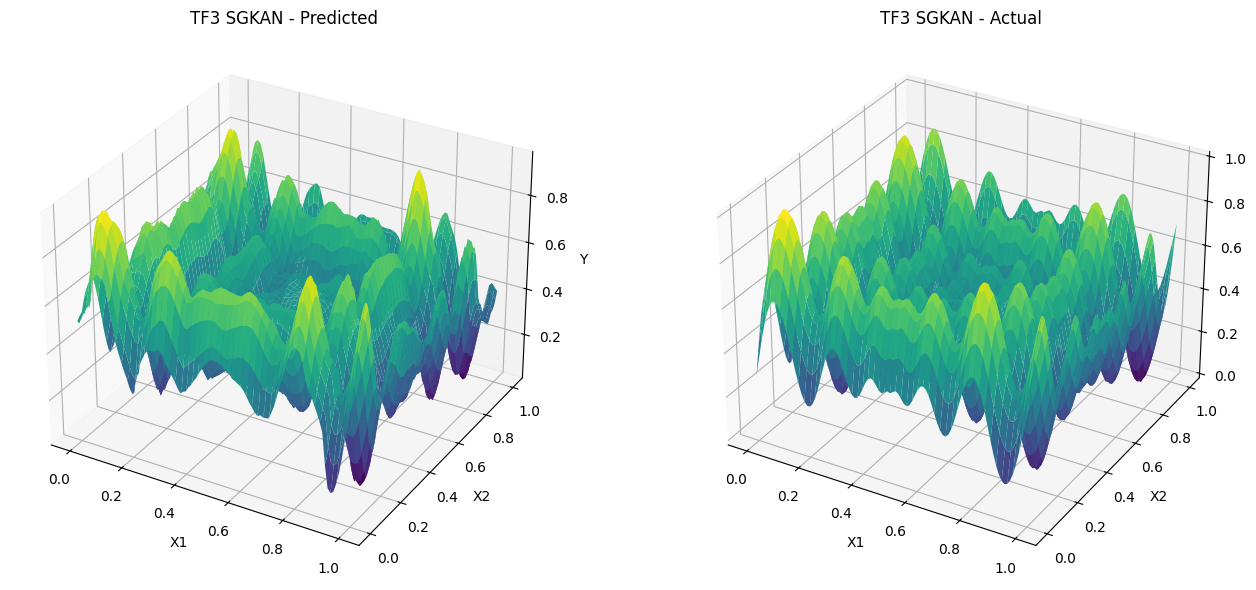

In [68]:
utils.plot_3d_surface("TF3 SGKAN", tf3_x_test, tf3_y_test, tf3_sgkan_y_test_pred)

# TF4 Experiments

## HKAN

In [69]:
# Load TF4 dataset
tf4 = load_dataset("TF4")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = tf4["train_input"], tf4["test_input"], tf4["train_label"], tf4["test_label"]

In [70]:
print("TF4 train describe")
display(pd.DataFrame(tf4_x_train).describe())
print("TF4 test describe")
display(pd.DataFrame(tf4_x_test).describe())
print("TF4 y_train describe")
display(pd.Series(tf4_y_train).describe())
print("TF4 y_test describe")
display(pd.Series(tf4_y_test).describe())

TF4 train describe


,0,1,2,3,4,5,6,7,8,9
count,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000,3750.000000
mean,0.506746,0.503204,0.498323,0.500772,0.497799,0.496639,0.495851,0.498425,0.493649,0.496010
std,0.283847,0.285025,0.293268,0.293257,0.288584,0.290085,0.288278,0.291463,0.286498,0.289600
min,0.000000,0.000254,0.000092,0.000000,0.000000,0.000227,0.000000,0.000000,0.000000,0.000000
25%,0.265375,0.260039,0.239920,0.244900,0.244162,0.242192,0.243826,0.241701,0.244787,0.240751
50%,0.510035,0.501595,0.495827,0.498848,0.498117,0.495226,0.487462,0.506830,0.498333,0.495502
75%,0.750690,0.744755,0.755315,0.756410,0.748974,0.751233,0.741759,0.750584,0.740535,0.749713
max,1.000000,0.999900,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


TF4 test describe


,0,1,2,3,4,5,6,7,8,9
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000
mean,0.498333,0.490395,0.486467,0.497279,0.513013,0.496188,0.497025,0.501470,0.506500,0.495865
std,0.293236,0.284424,0.290277,0.276920,0.288045,0.293981,0.289387,0.297975,0.287566,0.291880
min,0.000048,0.000000,0.000000,0.000001,0.000004,0.000000,0.000444,0.000265,0.000719,0.000455
25%,0.246033,0.245511,0.232735,0.259110,0.270409,0.248973,0.251188,0.239863,0.261810,0.242328
50%,0.496355,0.488314,0.476912,0.494997,0.524857,0.495540,0.494254,0.500964,0.511718,0.484211
75%,0.745779,0.746201,0.737399,0.744554,0.752652,0.744573,0.747964,0.760611,0.753214,0.748002
max,0.999627,1.000000,0.998885,0.999858,0.999300,0.999617,0.999495,0.999997,0.998615,0.999924


TF4 y_train describe


count    3750.000000
mean        0.552895
std         0.263216
min         0.069815
25%         0.292075
50%         0.551363
75%         0.813203
max         0.999973
dtype: float64

TF4 y_test describe


count    1250.000000
mean        0.552624
std         0.262334
min         0.000000
25%         0.297225
50%         0.550549
75%         0.807680
max         1.000000
dtype: float64

In [71]:
# TF4 HKAN model params
tf4_model_params = [
    {
        "layer": 0,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=3),
        "n_basis": 2,
        "centers": "equally_spaced",
        "regressor": Ridge(alpha=0.001),
    }
]
tf4_model = utils.build_hkan_from_params(tf4_model_params)
tf4_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,1
,n_basis,2
,centers,'equally_spaced'
,basis_fn,<hkan.hkan.Ta...t 0x315372390>
,base_regressor,Ridge(alpha=0.001)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [72]:
# Fit HKAN for TF4
utils.fit_hkan(tf4_model, tf4_x_train, tf4_y_train)
tf4_results = em.evaluate(
    tf4_model,
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 1058.10it/s]


✓ HKAN training completed in 0.0087 seconds


In [73]:
em.print_results(tf4_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.338550e-01         2.323804e-01        
RMSE            2.594233e-01         2.584713e-01        


✓ HKAN prediction completed in 0.0055 seconds
✓ Figure saved to results/TF4 HKAN_3d_surface.png


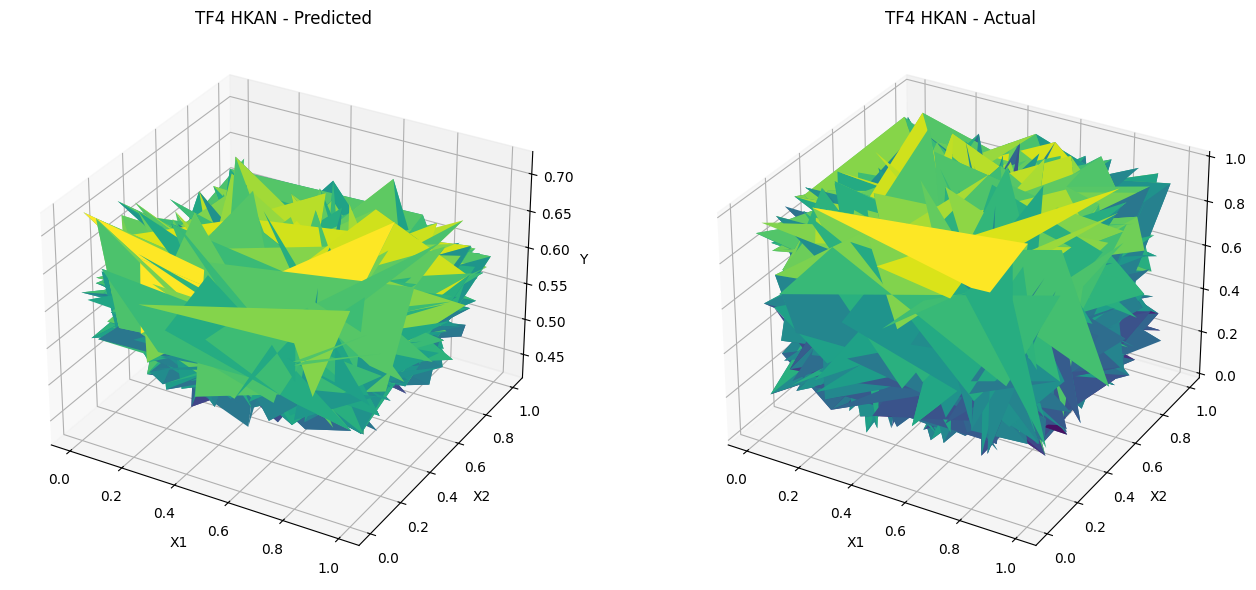

In [74]:
tf4_y_test_pred = utils.predict_hkan(tf4_model, tf4_x_test)
utils.plot_3d_surface("TF4 HKAN", tf4_x_test, tf4_y_test, tf4_y_test_pred)

## KAN

In [75]:
tf4_kan_study = utils.study_optuna_kan("TF4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, n_trials=10)

Results found for TF4. Loading from data/tf4_kan_optuna_search.csv
Best CV Validation RMSE: 0.263209
Best Test RMSE:          0.262005
Best width_idx:          1
Best architecture:       [10, 2, 1]

All 10 trials:
   number     value  params_width_idx  val_rmse  test_rmse
0       0  0.267264                 2  0.267264   0.264699
1       1  1.941438                 8  1.941438   0.578674
2       2  0.264042                 4  0.264042   0.262419
3       3  2.709694                 9  2.709694   0.873258
4       4  0.263209                 1  0.263209   0.262005
5       5  0.265406                 6  0.265406   0.262924
6       6  2.388389                 7  2.388389   0.611684
7       7  1.118305                 3  1.118305   1.554972
8       8  2.098387                 0  2.098387   2.034378
9       9  0.264162                 5  0.264162   0.267468


In [76]:
tf4_kan_model = utils.build_kan(width=tf4_kan_study["architecture"], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [77]:
utils.fit_kan(tf4_kan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, steps=100, opt="Adam", lamb=1e-3)

tf4_kan_results = em.evaluate(
    utils.KANModel(tf4_kan_model),
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

| train_loss: 2.63e-01 | test_loss: 2.62e-01 | reg: 1.15e+01 | : 100%|█| 100/100 [00:07<00:00, 14.11

saving model version 0.1

✓ KAN training completed in 7.0912 seconds


In [78]:
em.print_results(tf4_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.362001e-01         2.336923e-01        
RMSE            2.631507e-01         2.620049e-01        


✓ KAN prediction completed in 0.0060 seconds
✓ Figure saved to results/TF4 KAN_3d_surface.png


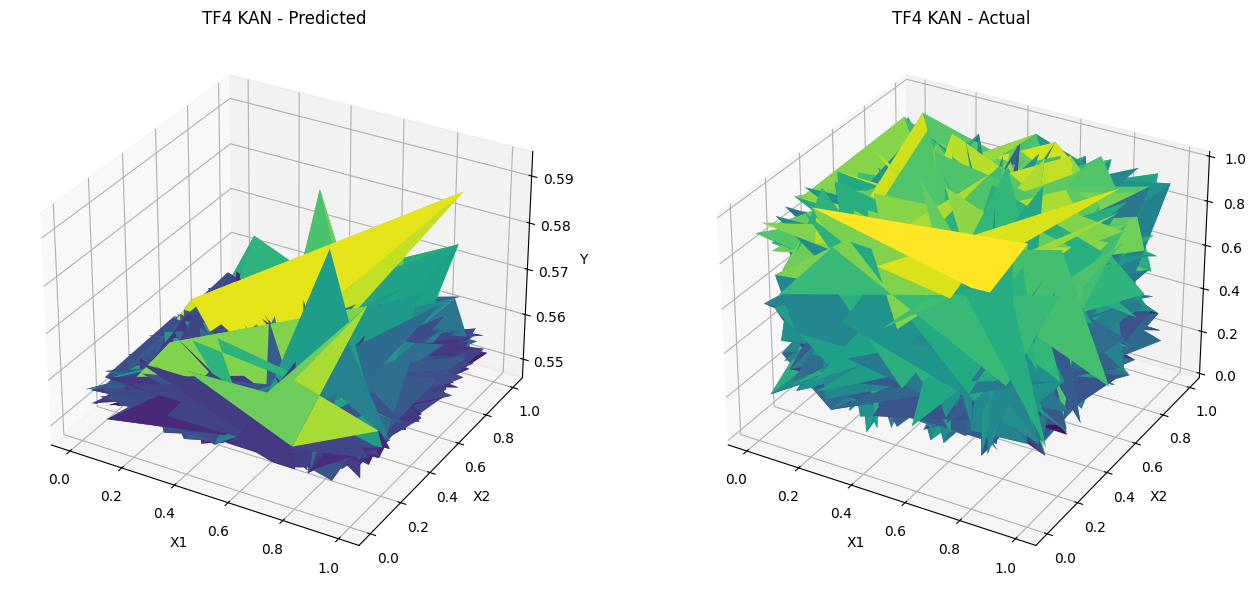

In [79]:
tf4_y_test_pred_kan = utils.predict_kan(tf4_kan_model, tf4_x_test)
utils.plot_3d_surface("TF4 KAN", tf4_x_test, tf4_y_test, tf4_y_test_pred_kan)

## GP

In [80]:
kernel_types = ["rbf", "matern", "rq", "periodic", "periodic_rbf", "periodic_linear"]
tf4_gp_study = utils.study_optuna_gp("TF4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, n_trials = 12, kernel_types=kernel_types)

Results found for TF4. Loading from data/tf4_gp_optuna_search.csv
Best CV Validation RMSE: 0.262297
Best Test RMSE:          0.259945
Best lr:                 0.004354
Best kernel:             periodic_rbf
Best num_inducing:       491

All 12 trials:
    number     value  params_lr    params_kernel  params_num_inducing  val_rmse  test_rmse
0        0  0.264185   0.005375              rbf                  326  0.264185   0.263004
1        1  0.263727   0.004262           matern                  300  0.263727   0.263228
2        2  0.263582   0.007608               rq                  336  0.263582   0.262360
3        3  0.500859   0.000223         periodic                  328  0.500859   0.472359
4        4  0.560773   0.000114     periodic_rbf                  497  0.560773   0.556538
5        5  0.271554   0.001182  periodic_linear                  356  0.271554   0.267766
6        6  0.528982   0.000183     periodic_rbf                  334  0.528982   0.514869
7        7  0.263104 

In [81]:
tf4_gp_study

{'lr': 0.0043535493168329, 'kernel': 'periodic_rbf', 'num_inducing': 491}

In [82]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf4_gp_study["kernel"], tf4_x_train)
tf4_gp_model, tf4_gp_likelihood = utils.init_and_fit_gp(
    tf4_x_train, tf4_y_train, kernel=kernel,
    num_inducing=tf4_gp_study["num_inducing"], lr=tf4_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf4_gp = utils.GPModel(tf4_gp_model, tf4_gp_likelihood)
tf4_gp_results = em.evaluate(
    tf4_gp,
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

em.print_results(tf4_gp_results)

# Make predictions for visualization
tf4_gp_y_test_pred = tf4_gp.predict(tf4_x_test)


Training GP...
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3750, 10]), num_inducing=491

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0043535493168329, loss=ELBO
  Iter 100/500, Loss: 1.159835
  Iter 200/500, Loss: 1.048895
  Iter 300/500, Loss: 0.982883
  Iter 400/500, Loss: 0.934726
  Iter 500/500, Loss: 0.897972
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.1802
  Noise: 0.693247
  Mean const: 0.4979
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             2.193455e-01         2.333836e-01        
RMSE            2.448031e-01         2.609436e-01        
[DEBUG] Sp

✓ Figure saved to results/TF4 GP_3d_surface.png


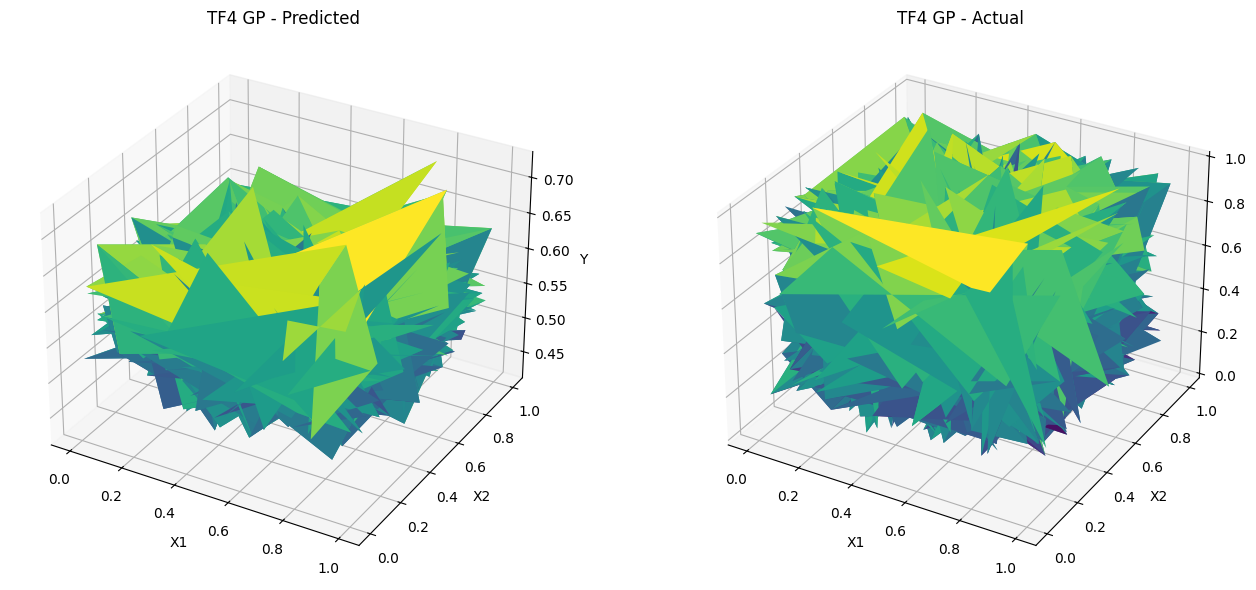

In [83]:
utils.plot_3d_surface("TF4 GP", tf4_x_test, tf4_y_test, tf4_gp_y_test_pred)

## SGKAN

In [84]:
tf4_gp_study

{'lr': 0.0043535493168329, 'kernel': 'periodic_rbf', 'num_inducing': 491}

In [85]:
tf4_sgkan_study = utils.study_optuna_sgkan(
    "TF4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, n_trials = 10,
    kernel=utils.kernel_factory(tf4_gp_study["kernel"], tf4_x_train), lr=tf4_gp_study["lr"], num_inducing=tf4_gp_study["num_inducing"])

Results found for TF4. Loading from data/tf4_sgkan_optuna_search.csv
Best CV Validation RMSE: 0.263088
Best Test RMSE:          0.259929
Best width:              37
Best M:                  856
Best G:                  81
Best T:                  38

All 10 trials:
   number     value  params_width  params_M  params_G  params_T  val_rmse  test_rmse
0       0  0.264985            95       758        34        36  0.264985   0.261345
1       1  0.268225           149       818        81        37  0.268225   0.263657
2       2  0.267769           184       876        63        30  0.267769   0.263854
3       3  0.265522           118       799        68        19  0.265522   0.261314
4       4  0.263088            37       856        81        38  0.263088   0.259929
5       5  0.265013           115       732        95        13  0.265013   0.260097
6       6  0.263351            40       530        62        50  0.263351   0.261720
7       7  0.267511           147       734        88 

In [86]:
tf4_sgkan_study

{'width': 37, 'M': 856, 'G': 81, 'T': 38}

In [87]:
tf4_sgkan_layers, tf4_sgkan_W_out = utils.fit_sgkan(
    tf4_x_train, tf4_y_train, 
    tf4_sgkan_study,
    num_inducing=tf4_gp_study["num_inducing"],
    lr=tf4_gp_study["lr"],
    activation=torch.tanh,
    kernel=utils.kernel_factory(tf4_gp_study["kernel"], tf4_x_train)
)


─── Layer 1 | input: torch.Size([3750, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3750, 10]), num_inducing=491
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0043535493168329, loss=ELBO
  Iter 100/500, Loss: 1.160481
  Iter 200/500, Loss: 1.048880
  Iter 300/500, Loss: 0.982684
  Iter 400/500, Loss: 0.934221
  Iter 500/500, Loss: 0.897314
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.1806
  Noise: 0.693247
  Mean const: 0.5031
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0087, max=0.0604, mean=0.0255
[DEBUG] Probs:  min=0.000399,  max=0.002772,  sum=1.000000
[DEBUG] Selected 37 pairs from 856 candidates
[DEBUG] Unique pairs selected: 36 / 37
[DEBUG] x_segments shape:     torch.Size([37, 81, 10])
[DEBUG] edge_functions shape: torch.Size([37, 81])
[DEBUG] Value range: [0.4496, 0.6876]
[DEBUG] H sha

In [88]:
tf4_sgkan_results = em.evaluate(
    utils.SGKANModel(tf4_sgkan_layers, tf4_sgkan_W_out, activation=torch.tanh),
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

[DEBUG] H shape: torch.Size([3750, 37])
[DEBUG] H value range: [0.4496, 0.6875]
[DEBUG] H rank (approx): 36
[DEBUG] H shape: torch.Size([1250, 37])
[DEBUG] H value range: [0.4496, 0.6875]
[DEBUG] H rank (approx): 36


In [89]:
em.print_results(tf4_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.339453e-01         2.338536e-01        
RMSE            2.604855e-01         2.621924e-01        


In [90]:
tf4_sgkan_y_test_pred = utils.predict_sgkan(tf4_sgkan_layers, tf4_sgkan_W_out, tf4_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([1250, 37])
[DEBUG] H value range: [0.4496, 0.6875]
[DEBUG] H rank (approx): 36
✓ Prediction completed in 0.0045 seconds


✓ Figure saved to results/TF4 SGKAN_3d_surface.png


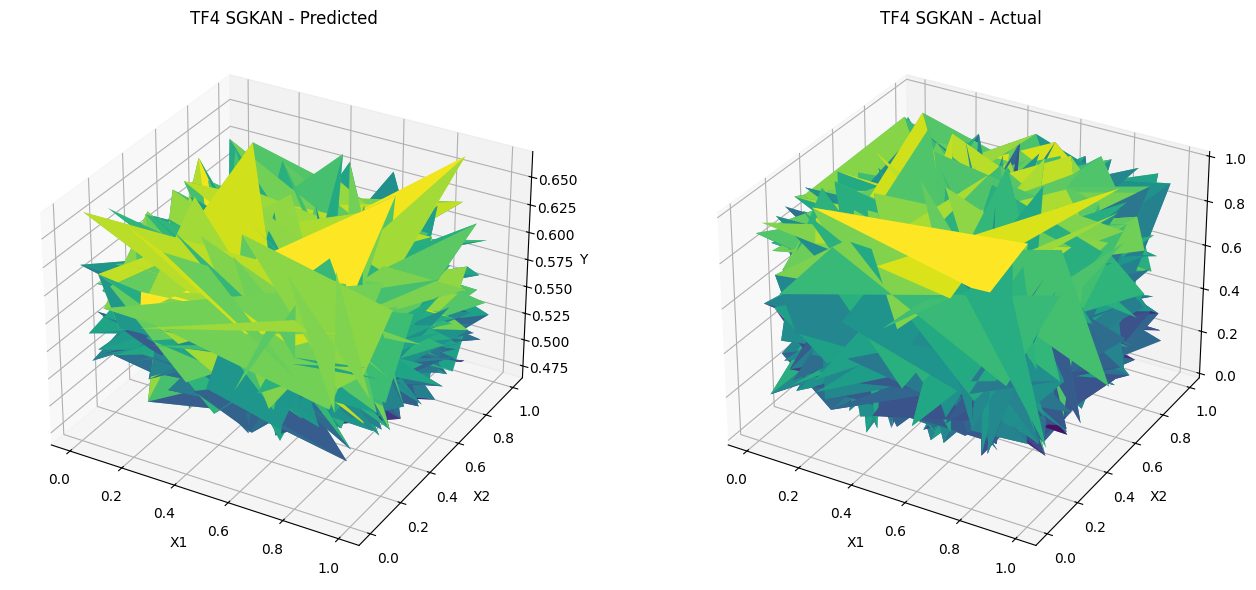

In [91]:
utils.plot_3d_surface("TF4 SGKAN", tf4_x_test, tf4_y_test, tf4_sgkan_y_test_pred)

# TF5 Experiments

## HKAN

In [92]:
# Load TF5 dataset
tf5 = load_dataset("TF5")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = tf5["train_input"], tf5["test_input"], tf5["train_label"], tf5["test_label"]

In [93]:
print("TF5 train describe")
display(pd.DataFrame(tf5_x_train).describe())
print("TF5 test describe")
display(pd.DataFrame(tf5_x_test).describe())
print("TF5 y_train describe")
display(pd.Series(tf5_y_train).describe())
print("TF5 y_test describe")
display(pd.Series(tf5_y_test).describe())

TF5 train describe


,0,1
count,5000.000000,5000.000000
mean,0.752401,0.750030
std,0.143031,0.142429
min,0.500216,0.500067
25%,0.630875,0.627742
50%,0.753696,0.749458
75%,0.874755,0.872681
max,0.999946,0.999991


TF5 test describe


,0,1
count,10000.000000,10000.000000
mean,0.750000,0.750000
std,0.145796,0.145796
min,0.500000,0.500000
25%,0.625000,0.625000
50%,0.750000,0.750000
75%,0.875000,0.875000
max,1.000000,1.000000


TF5 y_train describe


count    5000.000000
mean        0.884761
std         0.177206
min         0.007933
25%         0.818786
50%         0.991585
75%         0.999997
max         1.000000
dtype: float64

TF5 y_test describe


count    10000.000000
mean         0.884329
std          0.179202
min          0.000000
25%          0.818001
50%          0.992876
75%          0.999998
max          1.000000
dtype: float64

In [94]:
# tf5 HKAN model params
tf5_model_params = [
    {
        "layer": 0,
        "n_vars_out": 912,
        "basis_fn": Tanh(s=50),
        "n_basis": 23,
        "centers": "random",
        "regressor": Ridge(alpha=0.01),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(),
    }
]
tf5_model = utils.build_hkan_from_params(tf5_model_params)
tf5_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,912
,n_basis,23
,centers,'random'
,basis_fn,<hkan.hkan.Ta...t 0x1693d0590>
,base_regressor,Ridge(alpha=0.01)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [95]:
# Fit HKAN for TF5
utils.fit_hkan(tf5_model, tf5_x_train, tf5_y_train)
tf5_results = em.evaluate(
    tf5_model,
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.95it/s]



✓ HKAN training completed in 7.2555 seconds


In [96]:
em.print_results(tf5_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.137511e-13         2.543441e-13        
RMSE            2.594104e-13         3.572845e-13        


✓ HKAN prediction completed in 5.6541 seconds
✓ Figure saved to results/TF5 HKAN_3d_surface.png


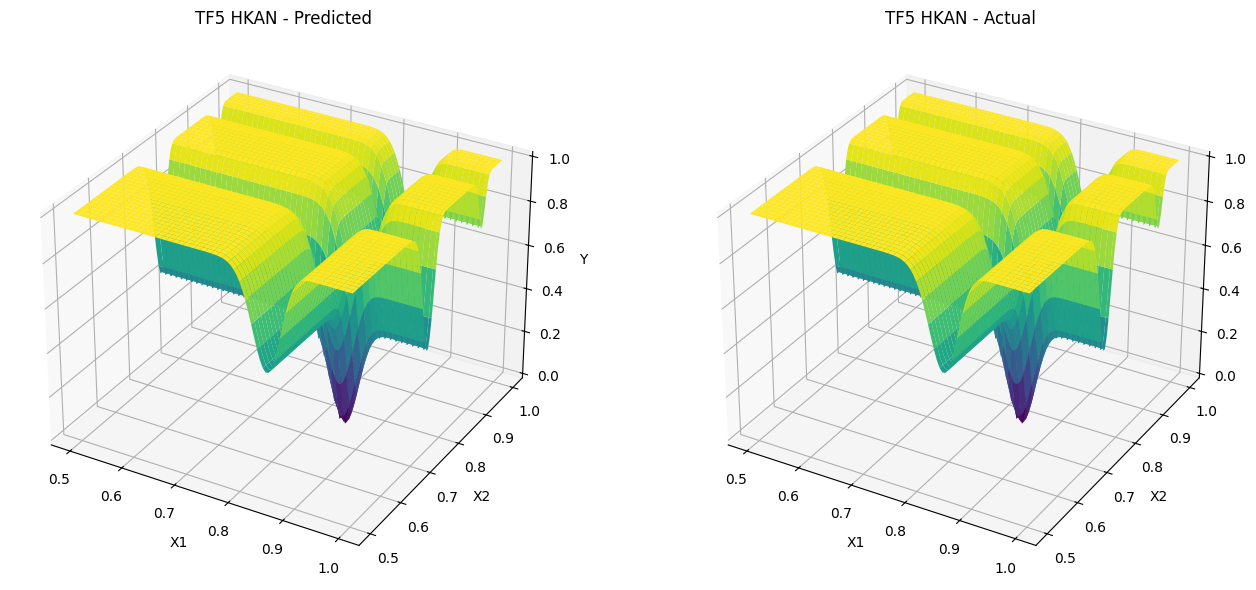

In [97]:
tf5_y_test_pred = utils.predict_hkan(tf5_model, tf5_x_test)
utils.plot_3d_surface("TF5 HKAN", tf5_x_test, tf5_y_test, tf5_y_test_pred)

## KAN

In [98]:
tf5_kan_study = utils.study_optuna_kan("TF5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, n_trials=10)

Results found for TF5. Loading from data/tf5_kan_optuna_search.csv
Best CV Validation RMSE: 0.177459
Best Test RMSE:          0.178417
Best width_idx:          0
Best architecture:       [2, 1]

All 10 trials:
   number     value  params_width_idx  val_rmse  test_rmse
0       0  0.196170                 2  0.196170   0.176963
1       1  0.336510                 8  0.336510   0.233948
2       2  0.537441                 4  0.537441   0.179316
3       3  0.673894                 9  0.673894   0.332759
4       4  0.186586                 1  0.186586   0.181430
5       5  0.347398                 6  0.347398   0.674302
6       6  0.382877                 7  0.382877   0.947079
7       7  0.183603                 3  0.183603   0.194581
8       8  0.177459                 0  0.177459   0.178417
9       9  0.644387                 5  0.644387   4.034507


In [99]:
tf5_kan_model = utils.build_kan(width=tf5_kan_study["architecture"], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [100]:
utils.fit_kan(tf5_kan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, steps=100, opt="Adam", lamb=1e-3)

tf5_kan_results = em.evaluate(
    utils.KANModel(tf5_kan_model),
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

| train_loss: 1.77e-01 | test_loss: 1.79e-01 | reg: 4.63e-01 | : 100%|█| 100/100 [00:19<00:00,  5.14


saving model version 0.1

✓ KAN training completed in 19.4620 seconds


In [101]:
em.print_results(tf5_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.415190e-01         1.427815e-01        
RMSE            1.765155e-01         1.784173e-01        


✓ KAN prediction completed in 0.0044 seconds
✓ Figure saved to results/TF5 KAN_3d_surface.png


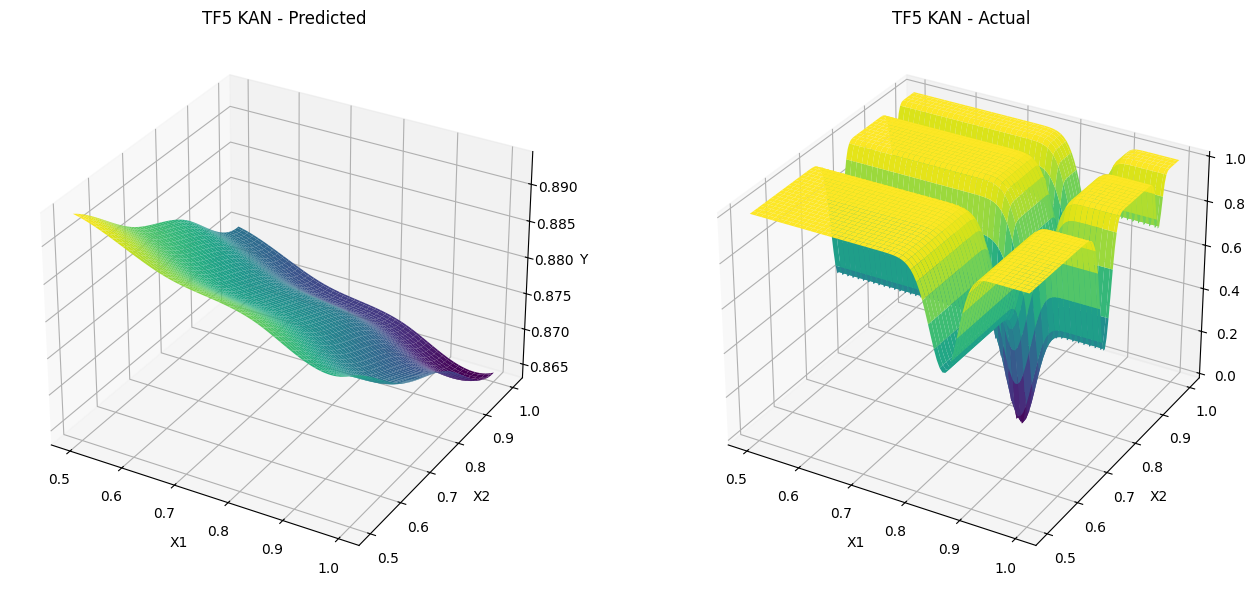

In [102]:
tf5_y_test_pred_kan = utils.predict_kan(tf5_kan_model, tf5_x_test)
utils.plot_3d_surface("TF5 KAN", tf5_x_test, tf5_y_test, tf5_y_test_pred_kan)

## GP

In [103]:
kernel_types = ["periodic", "periodic_rbf", "periodic_linear"]
tf5_gp_study = utils.study_optuna_gp("TF5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, n_trials = 10, kernel_types=kernel_types)

Results found for TF5. Loading from data/tf5_gp_optuna_search.csv
Best CV Validation RMSE: 0.087655
Best Test RMSE:          0.066079
Best lr:                 0.004408
Best kernel:             periodic_rbf
Best num_inducing:       406

All 10 trials:
   number     value  params_lr    params_kernel  params_num_inducing  val_rmse  test_rmse
0       0  0.110596   0.008943         periodic                  315  0.110596   0.078504
1       1  0.604951   0.000148     periodic_rbf                  484  0.604951   0.624610
2       2  0.154375   0.084200  periodic_linear                  493  0.154375   0.136858
3       3  0.104858   0.021097  periodic_linear                  405  0.104858   0.084770
4       4  0.123400   0.042257         periodic                  443  0.123400   0.076345
5       5  0.233418   0.000694  periodic_linear                  482  0.233418   0.267689
6       6  0.087655   0.004408     periodic_rbf                  406  0.087655   0.066079
7       7  0.103781   0.00329

In [104]:
tf5_gp_study

{'lr': 0.0044078474664702, 'kernel': 'periodic_rbf', 'num_inducing': 406}

In [105]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf5_gp_study["kernel"], tf5_x_train)
tf5_gp_model, tf5_gp_likelihood = utils.init_and_fit_gp(
    tf5_x_train, tf5_y_train, kernel=kernel,
    num_inducing=tf5_gp_study["num_inducing"], lr=tf5_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf5_gp = utils.GPModel(tf5_gp_model, tf5_gp_likelihood)
tf5_gp_results = em.evaluate(
    tf5_gp,
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

em.print_results(tf5_gp_results)

# Make predictions for visualization
tf5_gp_y_test_pred = tf5_gp.predict(tf5_x_test)


Training GP...
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=406

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0044078474664702, loss=ELBO
  Iter 100/500, Loss: 0.802635
  Iter 200/500, Loss: 0.771371
  Iter 300/500, Loss: 0.762872
  Iter 400/500, Loss: 0.759608
  Iter 500/500, Loss: 0.758261
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.5398
  Noise: 0.693247
  Mean const: 0.3080
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             7.770782e-02         7.774918e-02        
RMSE            1.043120e-01         1.051525e-01        
[DEBUG] Spa

✓ Figure saved to results/TF5 GP_3d_surface.png


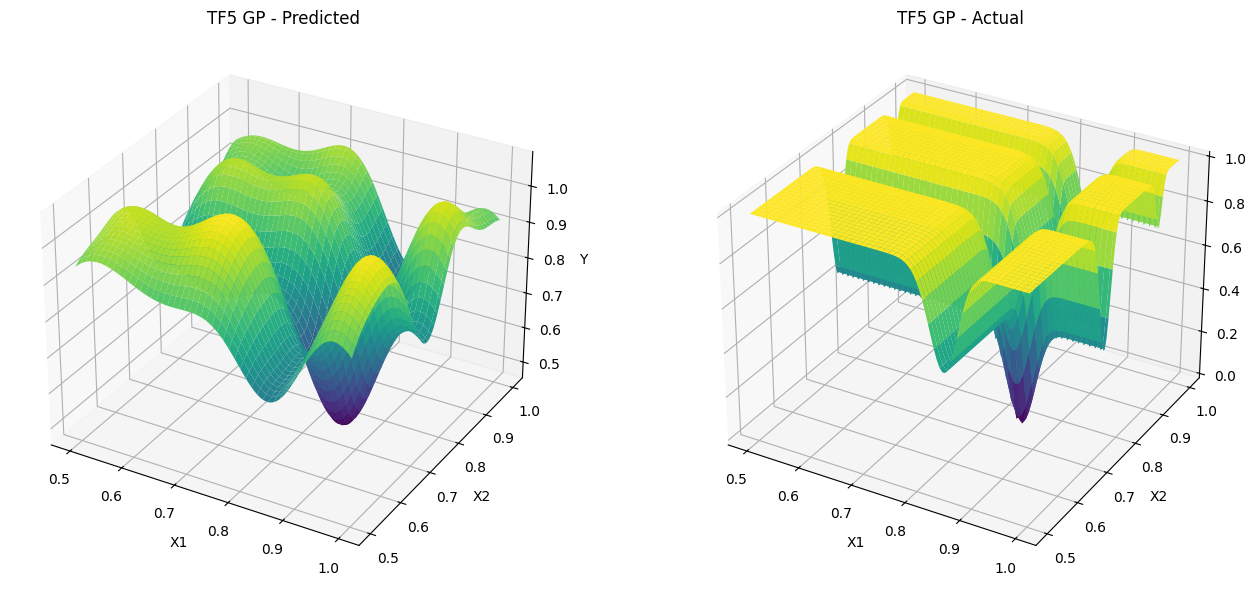

In [106]:
utils.plot_3d_surface("TF5 GP", tf5_x_test, tf5_y_test, tf5_gp_y_test_pred)

## SGKAN

In [107]:
tf5_sgkan_study = utils.study_optuna_sgkan(
    "TF5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, n_trials = 10,
    kernel=utils.kernel_factory(tf5_gp_study["kernel"], tf5_x_train), lr=tf5_gp_study["lr"], num_inducing=tf5_gp_study["num_inducing"])

Results found for TF5. Loading from data/tf5_sgkan_optuna_search.csv
Best CV Validation RMSE: 0.033293
Best Test RMSE:          0.026319
Best width:              141
Best M:                  800
Best G:                  98
Best T:                  8

All 10 trials:
   number     value  params_width  params_M  params_G  params_T  val_rmse  test_rmse
0       0  0.086775            44       793        69        45  0.086775   0.087005
1       1  0.061329            99       703        71        30  0.061329   0.060224
2       2  0.059061            61       760        84        36  0.059061   0.073379
3       3  0.043064           119       569        81        30  0.043064   0.052389
4       4  0.083915            56       809        30        19  0.083915   0.060786
5       5  0.034418           199       545        53         9  0.034418   0.032071
6       6  0.040763           121       906        96        43  0.040763   0.042820
7       7  0.041660           124       852        95 

In [108]:
tf5_sgkan_study

{'width': 141, 'M': 800, 'G': 98, 'T': 8}

In [109]:
tf5_sgkan_layers, tf5_sgkan_W_out = utils.fit_sgkan(
    tf5_x_train, tf5_y_train, 
    tf5_sgkan_study,
    num_inducing=tf5_gp_study["num_inducing"],
    lr=tf5_gp_study["lr"],
    activation=torch.tanh,
    kernel=utils.kernel_factory(tf5_gp_study["kernel"], tf5_x_train)
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=406
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0044078474664702, loss=ELBO
  Iter 100/500, Loss: 0.810622
  Iter 200/500, Loss: 0.774363
  Iter 300/500, Loss: 0.764738
  Iter 400/500, Loss: 0.760555
  Iter 500/500, Loss: 0.758495
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.5321
  Noise: 0.693247
  Mean const: 0.3475
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.1025, max=12.6689, mean=4.2631
[DEBUG] Probs:  min=0.000030,  max=0.003715,  sum=1.000000
[DEBUG] Selected 141 pairs from 800 candidates
[DEBUG] Unique pairs selected: 129 / 141
[DEBUG] x_segments shape:     torch.Size([141, 98, 2])
[DEBUG] edge_functions shape: torch.Size([141, 98])
[DEBUG] Value range: [0.4749, 1.0504]
[DEBUG] H 

In [110]:
tf5_sgkan_results = em.evaluate(
    utils.SGKANModel(tf5_sgkan_layers, tf5_sgkan_W_out, activation=torch.tanh),
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

[DEBUG] H shape: torch.Size([5000, 141])
[DEBUG] H value range: [0.4749, 1.0504]
[DEBUG] H rank (approx): 129
[DEBUG] H shape: torch.Size([10000, 141])
[DEBUG] H value range: [0.4749, 1.0504]
[DEBUG] H rank (approx): 129


In [111]:
em.print_results(tf5_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             3.383695e-02         3.531725e-02        
RMSE            4.698190e-02         4.878731e-02        


In [112]:
tf5_sgkan_y_test_pred = utils.predict_sgkan(tf5_sgkan_layers, tf5_sgkan_W_out, tf5_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([10000, 141])
[DEBUG] H value range: [0.4749, 1.0504]
[DEBUG] H rank (approx): 129
✓ Prediction completed in 0.0401 seconds


✓ Figure saved to results/TF5 SGKAN_3d_surface.png


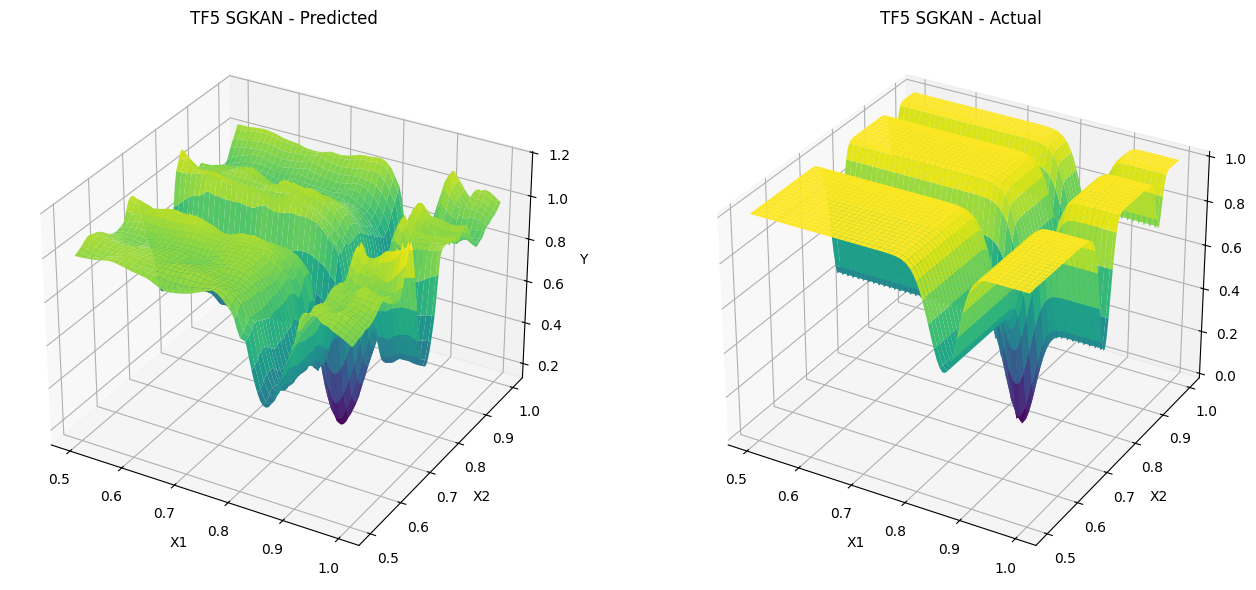

In [113]:
utils.plot_3d_surface("TF5 SGKAN", tf5_x_test, tf5_y_test, tf5_sgkan_y_test_pred)